In [1]:
import matplotlib.pyplot as plt
import pandas as pd


In [2]:

df = pd.read_excel('/Users/tish/Documents/Flexible Masters/02806 - Social data and visualization/CODE_Social_data_Visialization/TishDuc.github.io/Displacements_Final_Project/Data/UNHCR_Flow_Data.xlsx')
df.head()


,Source:,UNHCR Refugee population statistics database,Unnamed: 2,Unnamed: 3
0,Date extracted:,2025-11-03 00:00:00,NaN,NaN
1,Last updated:,2025-11-03 00:00:00,NaN,NaN
2,Some data presented may differ from statistics...,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,Data table contains the following:,"Demographic data, including location and accom...",NaN,NaN


In [3]:
xls = pd.ExcelFile('/Users/tish/Documents/Flexible Masters/02806 - Social data and visualization/CODE_Social_data_Visialization/TishDuc.github.io/Displacements_Final_Project/Data/UNHCR_Flow_Data.xlsx')
print(xls.sheet_names)

['Metadata', 'T23', 'SummaryByYear', 'SummaryByAsylum', 'DATA', 'Sheet1']


In [4]:
import pandas as pd

df = pd.read_excel('/Users/tish/Documents/Flexible Masters/02806 - Social data and visualization/CODE_Social_data_Visialization/TishDuc.github.io/Displacements_Final_Project/Data/UNHCR_Flow_Data.xlsx', sheet_name="DATA")
df.head()

,origin,OriginISO,OriginName,asylum,AsylumISO,AsylumName,AsylumRegion,Population types,Year,Count
0,ALG,DZA,Algeria,MTA,MLT,Malta,Europe,REF,1962,5
1,ANG,AGO,Angola,COD,COD,Dem. Rep. of the Congo,West and Central Africa,REF,1962,20000
2,ANG,AGO,Angola,NAM,NAM,Namibia,Eastern and Southern Africa,REF,1962,277
3,BDI,BDI,Burundi,NAM,NAM,Namibia,Eastern and Southern Africa,REF,1962,13
4,CHI,CHN,China,NEP,NPL,Nepal,Asia and the Pacific,REF,1962,5


In [5]:
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Count"] = pd.to_numeric(df["Count"], errors="coerce")

df = df.dropna(subset=["Year", "Count"])
df["Year"] = df["Year"].astype(int)

In [6]:
# Check for missing values
ref_df = df[df['Population types'] == "REF"].copy()

In [7]:
refugees_per_year = ref_df.groupby("Year")["Count"].sum().reset_index()
refugees_per_year.head()

,Year,Count
0,1962,22589
1,1963,25270
2,1964,163790
3,1965,135270
4,1966,143810


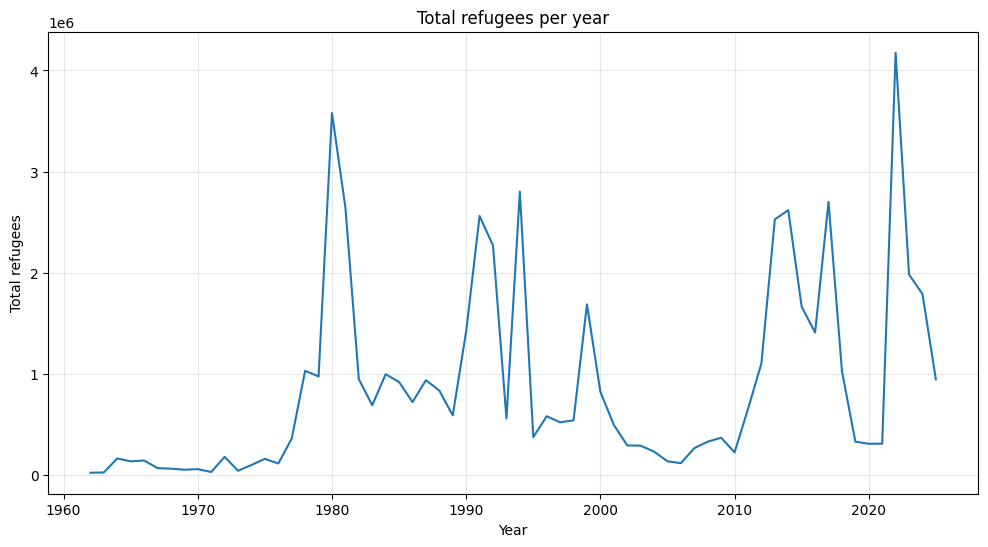

In [8]:
plt.figure(figsize=(12,6))
plt.plot(refugees_per_year["Year"], refugees_per_year["Count"])
plt.xlabel("Year")
plt.ylabel("Total refugees")
plt.title("Total refugees per year")
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
refugees_per_year["Count"] = refugees_per_year["Count"].astype(int)
refugees_per_year.head(10)

,Year,Count
0,1962,22589
1,1963,25270
2,1964,163790
3,1965,135270
4,1966,143810
5,1967,68180
6,1968,62500
7,1969,52400
8,1970,57980
9,1971,29720


In [10]:
pt_per_year = df.groupby(["Year", "PT"])["Count"].sum().reset_index()

plt.figure(figsize=(12,6))
for pt in pt_per_year["PT"].unique():
    subset = pt_per_year[pt_per_year["PT"] == pt]
    plt.plot(subset["Year"], subset["Count"], label=pt)

plt.xlabel("Year")
plt.ylabel("Total count")
plt.title("Total displaced people per year by category")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

KeyError: 'PT'

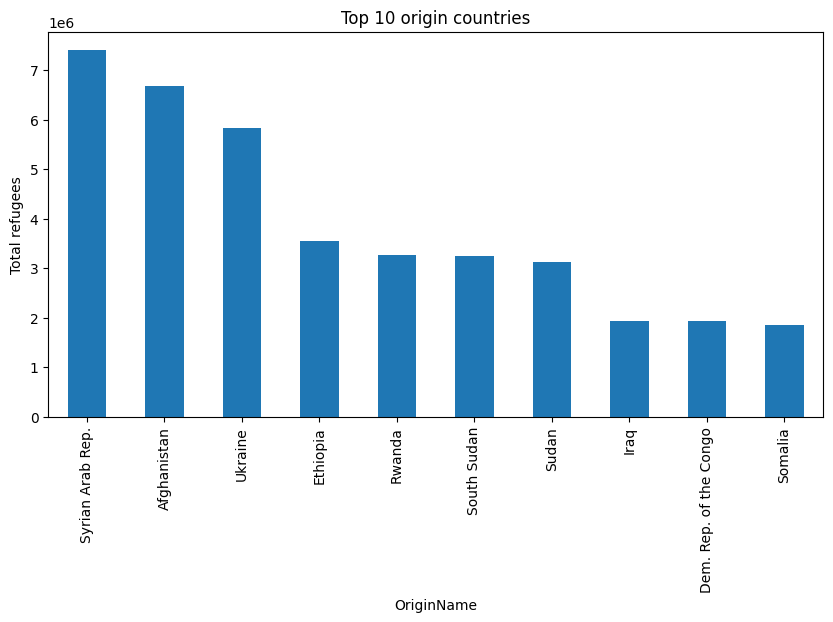

In [ ]:
top_origins = (
    ref_df.groupby("OriginName")["Count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_origins.plot(kind="bar", figsize=(10,5), title="Top 10 origin countries")
plt.ylabel("Total refugees")
plt.show()